<a href="https://colab.research.google.com/github/Aditya-2005917/projects-DataScience/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [919]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')


In [920]:
df=pd.read_csv('/content/Housing price prediction.csv')
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [921]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [922]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [984]:
df.duplicated().sum()

np.int64(0)

## No. Null Values
- 0 null values
## Data Types
- all datatypes are correct
## Duplicates
- No duplicates(0-duplicates)


In [923]:
data=df.copy()

In [924]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [925]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [926]:
data.describe(percentiles=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
10%,2.835000e+06,3000.000000,2.000000,1.000000,1.000000,0.000000
20%,3.290000e+06,3450.000000,2.000000,1.000000,1.000000,0.000000
30%,3.605000e+06,3664.000000,3.000000,1.000000,1.000000,0.000000
40%,3.990000e+06,4065.000000,3.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
60%,4.830000e+06,5400.000000,3.000000,1.000000,2.000000,1.000000


In [927]:
def detect_outliers_iqr(data, column):
  Q1 = data[column].quantile(0.25)
  Q3 = data[column].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
  return outliers, lower_bound, upper_bound
outliers_price, lb_price, ub_price = detect_outliers_iqr(data, 'price')
print(f"Lower bound: {lb_price}, Upper bound: {ub_price}")
print(f"Number of outliers in price: {len(outliers_price)}")
print("---------------------------------")
outliers_stories, lb_stories, ub_stories = detect_outliers_iqr(data, 'stories')
print(f"Lower bound: {lb_stories}, Upper bound: {ub_stories}")
print(f"Number of outliers in stories: {len(outliers_stories)}")
print("---------------------------------")
outliers_area, lb_area, ub_area = detect_outliers_iqr(data, 'area')
outliers_parking, lb_parking, ub_parking = detect_outliers_iqr(data, 'parking')
print(f"Lower bound: {lb_area}, Upper bound: {ub_area}")
print(f"Number of outliers in area : {len(outliers_area)}")
print("---------------------------------")
print(f"Lower bound: {lb_parking}, Upper bound: {ub_parking}")
print(f"Number of outliers in parking: {len(outliers_parking)}")
print("---------------------------------")
outliers_bedrooms, lb_bedrooms, ub_bedrooms = detect_outliers_iqr(data, 'bedrooms')
outliers_bathrooms, lb_bathrooms, ub_bathrooms = detect_outliers_iqr(data, 'bathrooms')
print(f"Lower bound: {lb_bedrooms}, Upper bound: {ub_bedrooms}")
print(f"Number of outliers in bedrooms : {len(outliers_bedrooms)}")
print("---------------------------------")
print(f"Lower bound: {lb_bathrooms}, Upper bound: {ub_bathrooms}")
print(f"Number of outliers in bathrooms: {len(outliers_bathrooms)}")

Lower bound: -35000.0, Upper bound: 9205000.0
Number of outliers in price: 15
---------------------------------
Lower bound: -0.5, Upper bound: 3.5
Number of outliers in stories: 41
---------------------------------
Lower bound: -540.0, Upper bound: 10500.0
Number of outliers in area : 12
---------------------------------
Lower bound: -1.5, Upper bound: 2.5
Number of outliers in parking: 12
---------------------------------
Lower bound: 0.5, Upper bound: 4.5
Number of outliers in bedrooms : 12
---------------------------------
Lower bound: -0.5, Upper bound: 3.5
Number of outliers in bathrooms: 1


In [928]:
col = data.select_dtypes(include=[int]).columns
col

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')

<Axes: ylabel='area'>

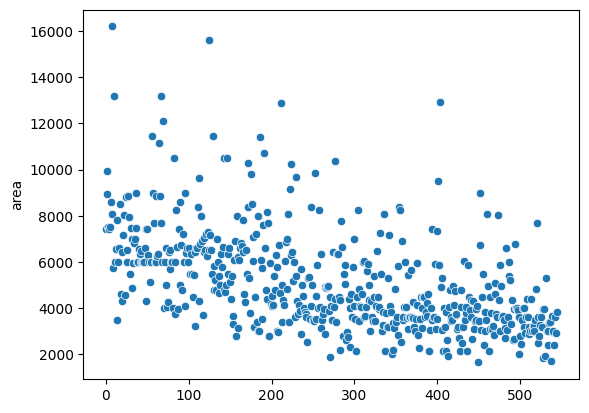

In [929]:
sns.scatterplot(data=data['area'])

<Axes: ylabel='price'>

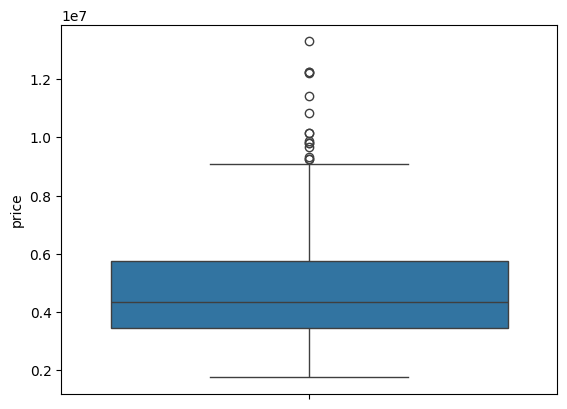

In [930]:
sns.boxplot(data['price'])


<Axes: ylabel='area'>

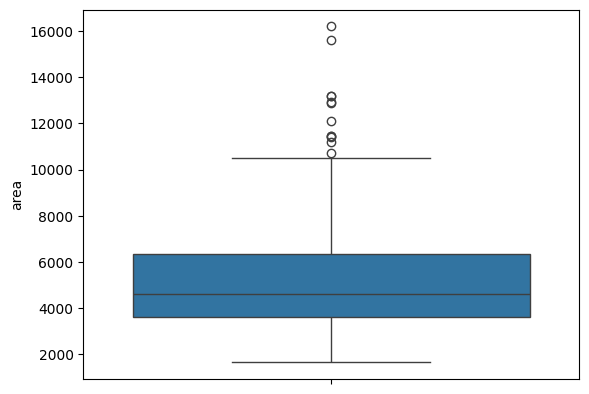

In [931]:
sns.boxplot(data['area'])

<Axes: ylabel='bedrooms'>

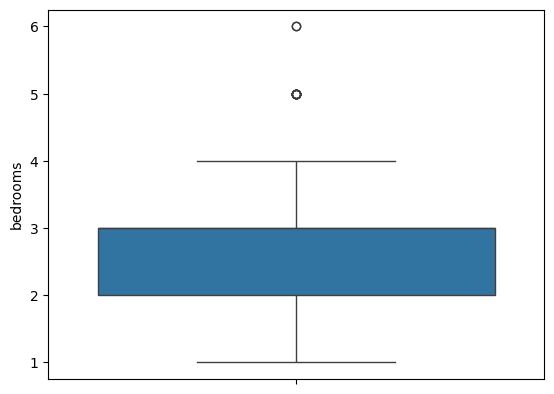

In [932]:
sns.boxplot(data['bedrooms'])


<Axes: ylabel='bathrooms'>

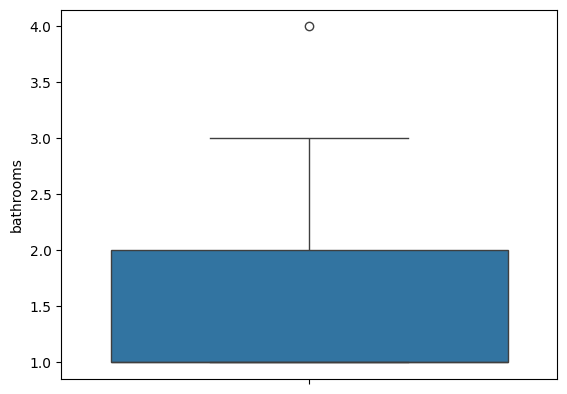

In [933]:
sns.boxplot(data['bathrooms'])

<Axes: ylabel='stories'>

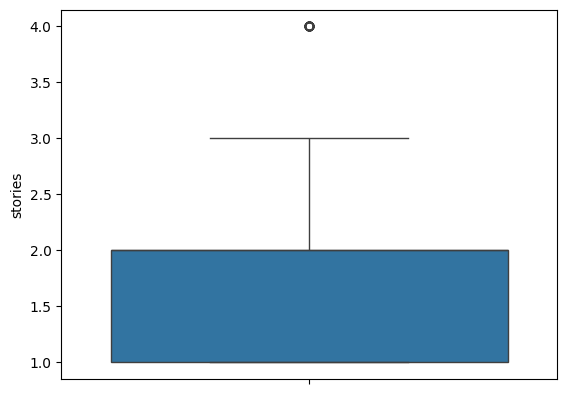

In [934]:
sns.boxplot(data['stories'])

<Axes: ylabel='parking'>

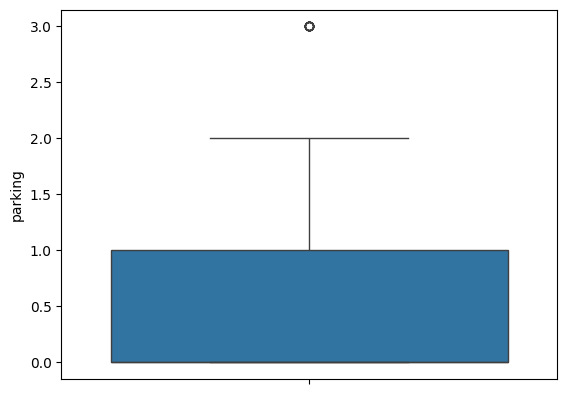

In [935]:
sns.boxplot(data['parking'])

In [936]:
def cap_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data.loc[data[col] < lower_bound, col] = lower_bound
    data.loc[data[col] > upper_bound, col] = upper_bound

    return data

data = cap_outliers(data, 'price')

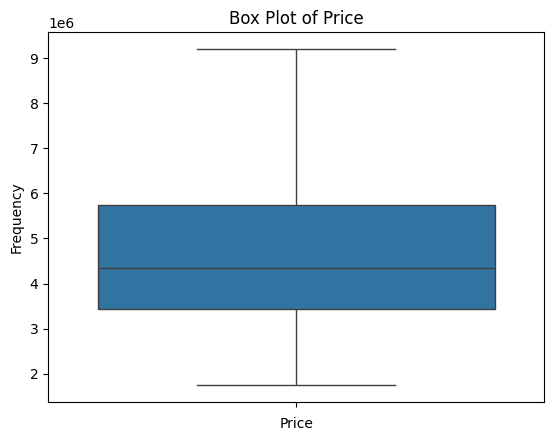

In [937]:
sns.boxplot(data=data['price'])
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Box Plot of Price')
plt.show()

In [938]:

data = cap_outliers(data, 'area')

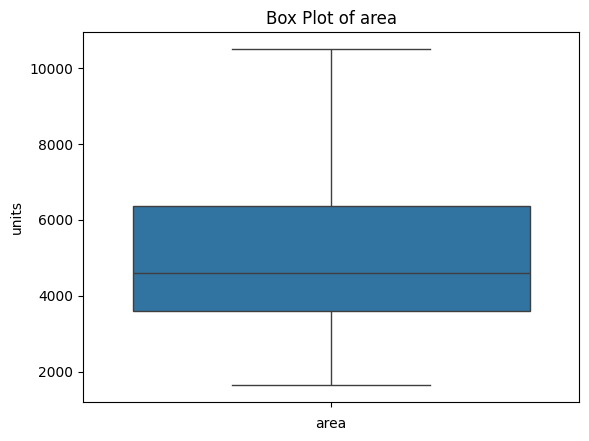

In [939]:
sns.boxplot(data=data['area'])
plt.xlabel('area')
plt.ylabel('units')
plt.title('Box Plot of area')
plt.show()

In [940]:
data = cap_outliers(data, 'bedrooms')

<Axes: ylabel='bedrooms'>

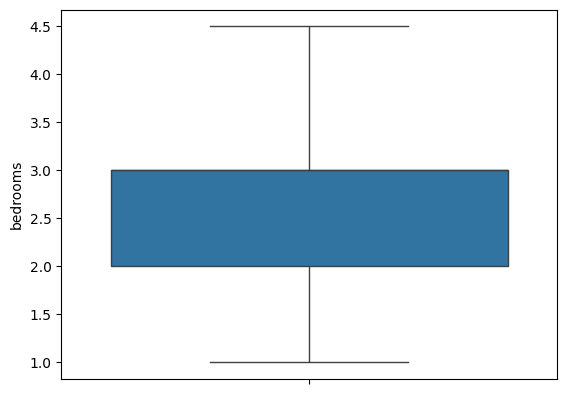

In [941]:
sns.boxplot(data['bedrooms'])

In [942]:
data = cap_outliers(data, 'bathrooms')
data = cap_outliers(data, 'stories')
data = cap_outliers(data, 'parking')

<Axes: ylabel='bathrooms'>

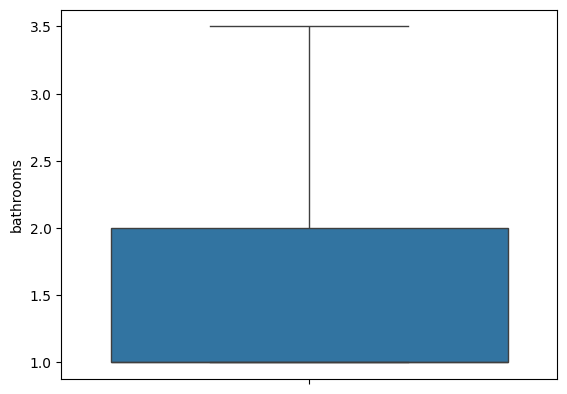

In [943]:
sns.boxplot(data['bathrooms'])

<Axes: ylabel='stories'>

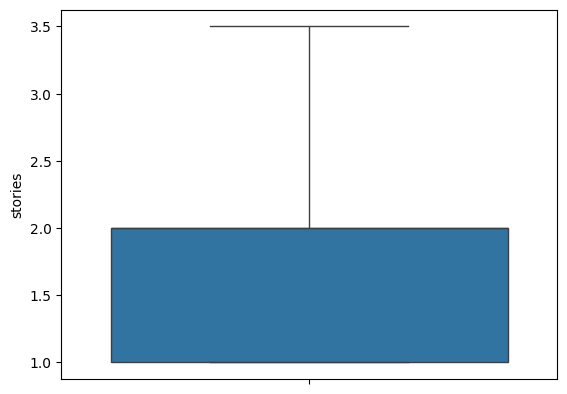

In [944]:
sns.boxplot(data['stories'])


<Axes: ylabel='parking'>

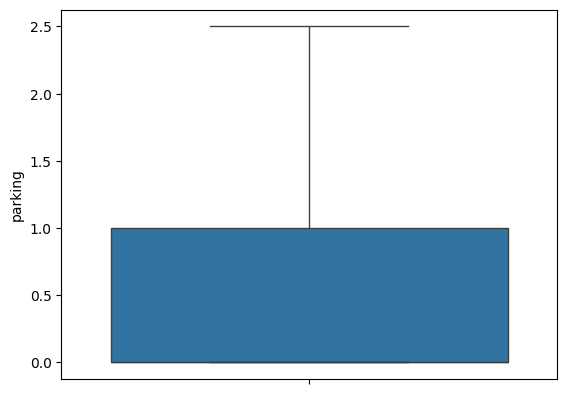

In [945]:
sns.boxplot(data['parking'])

✅ Final Notes
- The dataset is free of missing values.
- Outliers have been handled by capping, ensuring no extreme distortions.
- Data types are consistent and ready for further analysis, visualization, or modeling.


In [946]:
numeric_cols=data.loc[:,col]
numeric_cols.head()

,price,area,bedrooms,bathrooms,stories,parking
0,9205000,7420,4.0,2.0,3.0,2.0
1,9205000,8960,4.0,3.5,3.5,2.5
2,9205000,9960,3.0,2.0,2.0,2.0
3,9205000,7500,4.0,2.0,2.0,2.5
4,9205000,7420,4.0,1.0,2.0,2.0


In [947]:
numeric_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   price      545 non-null    int64  
 1   area       545 non-null    int64  
 2   bedrooms   545 non-null    float64
 3   bathrooms  545 non-null    float64
 4   stories    545 non-null    float64
 5   parking    545 non-null    float64
dtypes: float64(4), int64(2)
memory usage: 25.7 KB


In [948]:
numeric_cols.corr()

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.553876,0.381802,0.508576,0.415874,0.380769
area,0.553876,1.000000,0.159563,0.198013,0.076002,0.367799
bedrooms,0.381802,0.159563,1.000000,0.379505,0.449893,0.149738
bathrooms,0.508576,0.198013,0.379505,1.000000,0.314988,0.175172
stories,0.415874,0.076002,0.449893,0.314988,1.000000,0.028590
parking,0.380769,0.367799,0.149738,0.175172,0.028590,1.000000


In [949]:
numeric_cols['price'].corr(numeric_cols['area'])

np.float64(0.5538764249373572)

In [950]:
numeric_cols['price'].corr(numeric_cols['bedrooms'])

np.float64(0.3818024788411794)

In [951]:
numeric_cols['price'].corr(numeric_cols['bathrooms'])

np.float64(0.5085760387066195)

In [952]:
numeric_cols['price'].corr(numeric_cols['parking'])

np.float64(0.38076854828098644)

<Axes: >

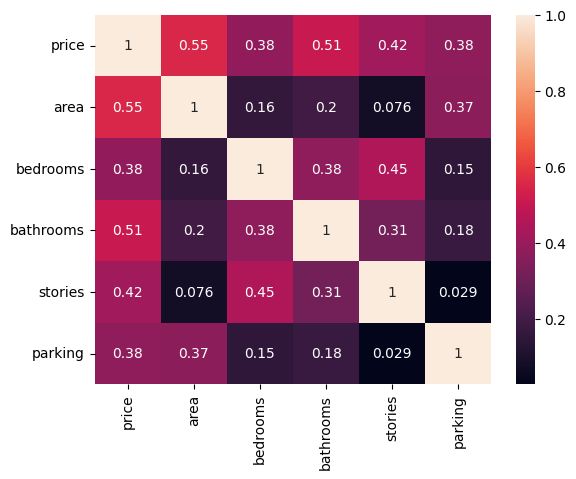

In [953]:
sns.heatmap(numeric_cols.corr(),annot=True)


- Price vs Area (0.55) → Moderate positive correlation. Larger houses tend to have higher prices, but it’s not a perfect relationship.
- Price vs Bathrooms (0.51) → Stronger correlation than bedrooms. Bathrooms seem to influence price more than the number of bedrooms.
- Price vs Stories (0.42) → Moderate correlation. More stories generally increase price, but not as strongly as area or bathrooms.
- Price vs Bedrooms (0.38) → Weaker correlation compared to bathrooms. Bedrooms alone don’t drive price as much.
- Price vs Parking (0.38) → Similar to bedrooms. Parking availability matters, but not as strongly as area or bathrooms.

✅ Conclusions
- Area and bathrooms are the strongest predictors of price in this dataset.
- Bedrooms and parking matter, but less strongly — they add value but aren’t the main drivers.
- Stories show moderate influence, likely tied to overall house size and design.
- No feature shows a negative correlation with price, meaning all these factors generally increase value.



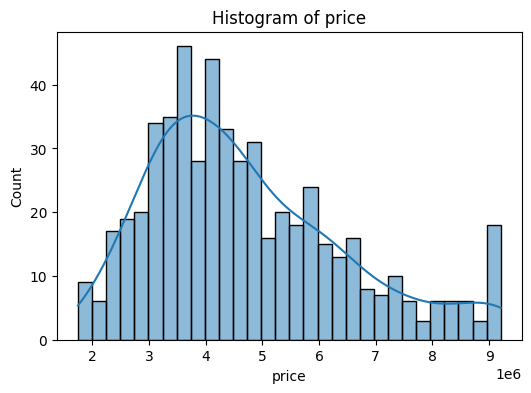

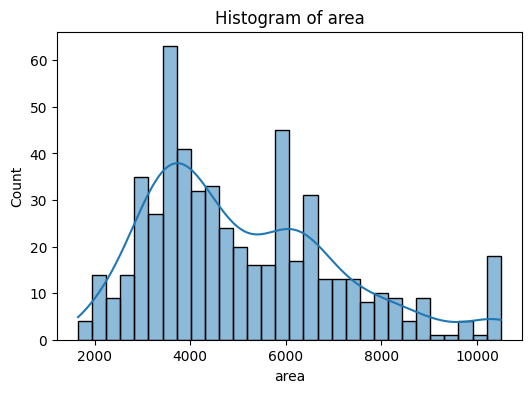

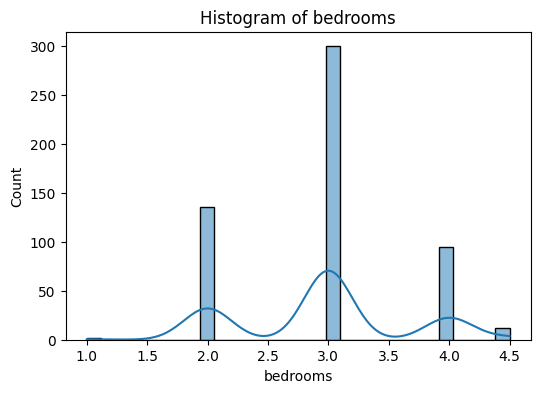

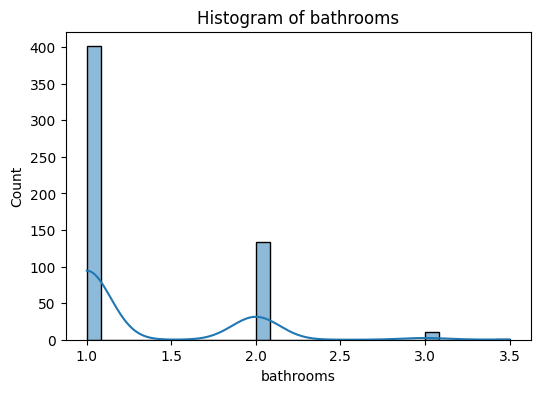

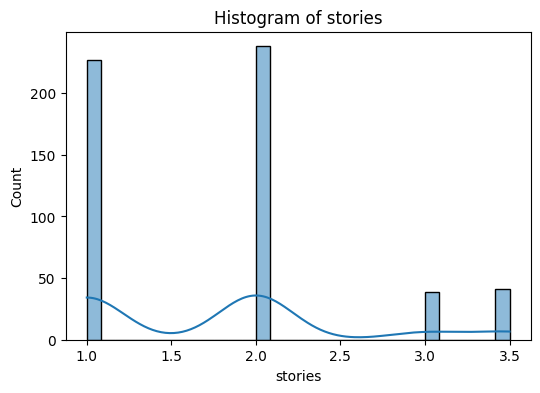

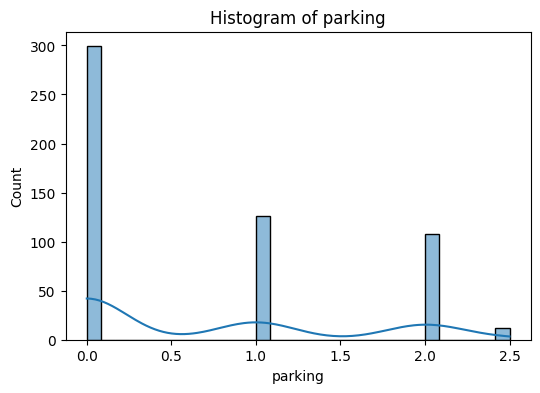

In [954]:
for col in numeric_cols.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(numeric_cols[col], kde=True, bins=30)
    plt.title(f"Histogram of {col}")
    plt.show()

In [955]:
numeric_cols['price'].skew()


np.float64(0.8066723525077296)

In [956]:
numeric_cols['area'].skew()

np.float64(0.8075109597834306)

In [957]:
numeric_cols['bathrooms'].skew()

np.float64(1.5020284640091277)

In [958]:
numeric_cols['price_log'] = np.log(numeric_cols['price'])


In [959]:
numeric_cols['area_log'] = np.log(numeric_cols['area'])

In [960]:
numeric_cols['bathrooms_log'] = np.log(numeric_cols['bathrooms'])

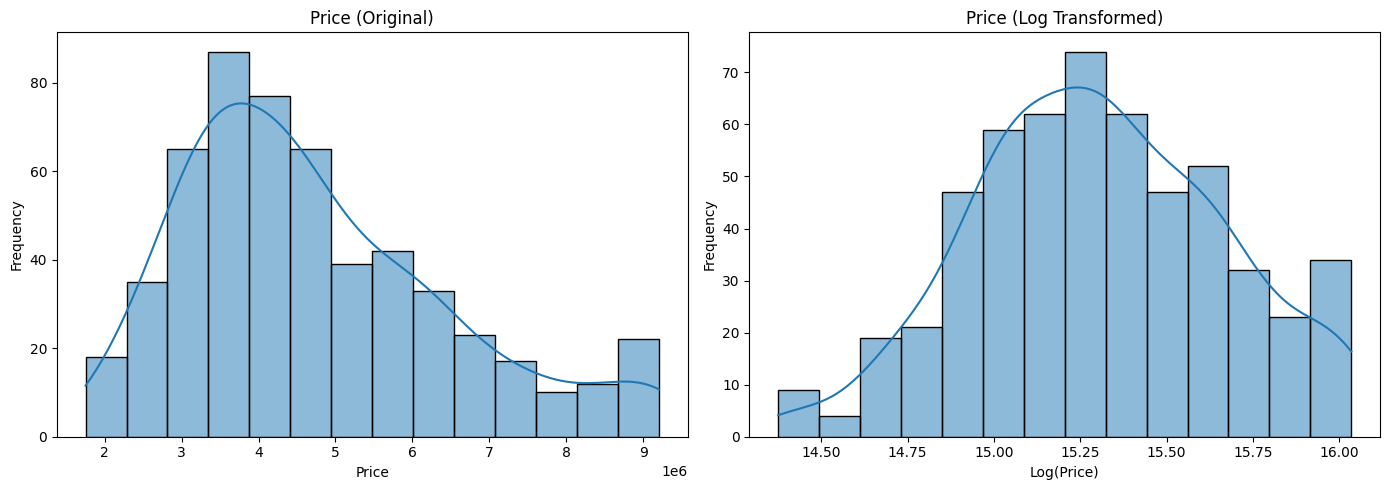

In [961]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(numeric_cols['price'], kde=True, ax=axes[0])
axes[0].set_title("Price (Original)")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Frequency")

sns.histplot(numeric_cols['price_log'], kde=True, ax=axes[1])
axes[1].set_title("Price (Log Transformed)")
axes[1].set_xlabel("Log(Price)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

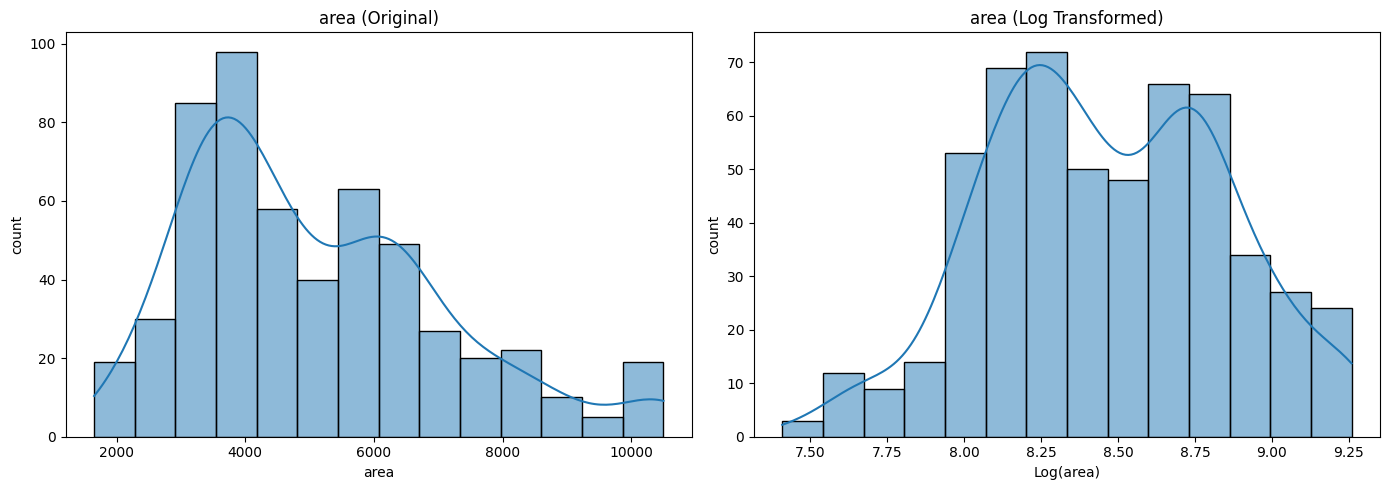

In [962]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(numeric_cols['area'], kde=True, ax=axes[0],stat="count")
axes[0].set_title("area (Original)")
axes[0].set_xlabel("area")
axes[0].set_ylabel("count")

sns.histplot(numeric_cols['area_log'], kde=True, ax=axes[1],stat="count")
axes[1].set_title("area (Log Transformed)")
axes[1].set_xlabel("Log(area)")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

In [963]:
# pip install category_encoders

In [964]:
import category_encoders as ce

In [965]:
encodeddata=df.loc[:,['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea','furnishingstatus']]

In [966]:
encodeddata['furnishingstatus'].value_counts()

,count
furnishingstatus,
semi-furnished,227
unfurnished,178
furnished,140


In [967]:
encodeddata.head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,yes,no,no,no,yes,yes,furnished
1,yes,no,no,no,yes,no,furnished
2,yes,no,yes,no,no,yes,semi-furnished
3,yes,no,yes,no,yes,yes,furnished
4,yes,yes,yes,no,yes,no,furnished


In [968]:
# Suppose you have a column 'mainroad' with values 'Yes' and 'No'
encodeddata['mainroad'] = data['mainroad'].map({'yes': 1, 'no': 0})

# Similarly for 'guestroom'
encodeddata['guestroom'] = data['guestroom'].map({'yes': 1, 'no': 0})
encodeddata['basement'] = data['basement'].map({'yes': 1, 'no': 0})

# Similarly for 'guestroom'
encodeddata['hotwaterheating'] = data['hotwaterheating'].map({'yes': 1, 'no': 0})
encodeddata['airconditioning'] = data['airconditioning'].map({'yes': 1, 'no': 0})

# Similarly for 'guestroom'
encodeddata['prefarea'] = data['prefarea'].map({'yes': 1, 'no': 0})

In [969]:
encodeddata.head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,1,0,0,0,1,1,furnished
1,1,0,0,0,1,0,furnished
2,1,0,1,0,0,1,semi-furnished
3,1,0,1,0,1,1,furnished
4,1,1,1,0,1,0,furnished


In [970]:
encodeddata = pd.get_dummies(encodeddata, columns=['furnishingstatus'], drop_first=False)
encodeddata.head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1,0,0,0,1,1,True,False,False
1,1,0,0,0,1,0,True,False,False
2,1,0,1,0,0,1,False,True,False
3,1,0,1,0,1,1,True,False,False
4,1,1,1,0,1,0,True,False,False


In [971]:
encodeddata.rename(columns={
    'furnishingstatus_furnished': 'furnished',
    'furnishingstatus_semi-furnished': 'semi-furnished',
    'furnishingstatus_unfurnished': 'unfurnished'
}, inplace=True)


In [972]:
encodeddata.head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnished,semi-furnished,unfurnished
0,1,0,0,0,1,1,True,False,False
1,1,0,0,0,1,0,True,False,False
2,1,0,1,0,0,1,False,True,False
3,1,0,1,0,1,1,True,False,False
4,1,1,1,0,1,0,True,False,False


In [973]:
encodeddata['furnished'] = encodeddata['furnished'].astype(int)
encodeddata['semi-furnished'] = encodeddata['semi-furnished'].astype(int)
encodeddata['unfurnished'] = encodeddata['unfurnished'].astype(int)

In [974]:
encodeddata.head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnished,semi-furnished,unfurnished
0,1,0,0,0,1,1,1,0,0
1,1,0,0,0,1,0,1,0,0
2,1,0,1,0,0,1,0,1,0
3,1,0,1,0,1,1,1,0,0
4,1,1,1,0,1,0,1,0,0


In [975]:

numeric_cols['price_per_sqft'] = numeric_cols['price'] / numeric_cols['area']

# Bathrooms per bedroom
numeric_cols['bath_per_bedroom'] = numeric_cols['bathrooms'] / numeric_cols['bedrooms']


In [976]:
numeric_cols.head()

,price,area,bedrooms,bathrooms,stories,parking,price_log,area_log,bathrooms_log,price_per_sqft,bath_per_bedroom
0,9205000,7420,4.0,2.0,3.0,2.0,16.035257,8.911934,0.693147,1240.566038,0.500000
1,9205000,8960,4.0,3.5,3.5,2.5,16.035257,9.100526,1.252763,1027.343750,0.875000
2,9205000,9960,3.0,2.0,2.0,2.0,16.035257,9.206332,0.693147,924.196787,0.666667
3,9205000,7500,4.0,2.0,2.0,2.5,16.035257,8.922658,0.693147,1227.333333,0.500000
4,9205000,7420,4.0,1.0,2.0,2.0,16.035257,8.911934,0.000000,1240.566038,0.250000


In [978]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Standardization (mean=0, std=1)
scaler = StandardScaler()
data_scaled = numeric_cols.copy()
data_scaled[numeric_cols.columns] = scaler.fit_transform(numeric_cols[numeric_cols.columns])

# Alternatively: Min-Max scaling (range 0–1)
minmax = MinMaxScaler()
data_minmax = numeric_cols.copy()
data_minmax[numeric_cols.columns] = minmax.fit_transform(numeric_cols[numeric_cols.columns])

In [979]:
data_scaled

,price,area,bedrooms,bathrooms,stories,parking,price_log,area_log,bathrooms_log,price_per_sqft,bath_per_bedroom
0,2.567990,1.156583,1.506093,1.436585,1.586075,1.579640,2.016159,1.156830,1.543672,0.737000,0.333524
1,2.567990,1.925060,1.506093,4.451753,2.229717,2.179156,2.016159,1.642297,3.266102,0.107888,2.701013
2,2.567990,2.424072,0.071092,1.436585,0.298791,1.579640,2.016159,1.914662,1.543672,-0.196447,1.385741
3,2.567990,1.196504,1.506093,1.436585,0.298791,2.179156,2.016159,1.184435,1.543672,0.697956,0.333524
4,2.567990,1.156583,1.506093,-0.573527,0.298791,1.579640,2.016159,1.156830,-0.589753,0.737000,-1.244802
...,...,...,...,...,...,...,...,...,...,...,...
540,-1.667438,-1.049046,-1.363909,-0.573527,-0.988492,1.579640,-2.448016,-1.174257,-0.589753,-1.133319,0.333524
541,-1.697749,-1.348453,0.071092,-0.573527,-0.988492,-0.818421,-2.529176,-1.748667,-0.589753,-0.750799,-0.718693
542,-1.707585,-0.739659,-1.363909,-0.573527,-0.988492,-0.818421,-2.556035,-0.690668,-0.589753,-1.496942,0.333524
543,-1.707585,-1.093957,0.071092,-0.573527,-0.988492,-0.818421,-2.556035,-1.252664,-0.589753,-1.148934,-0.718693


In [980]:
data_minmax


,price,area,bedrooms,bathrooms,stories,parking,price_log,area_log,bathrooms_log,price_per_sqft,bath_per_bedroom
0,1.00000,0.651977,0.857143,0.4,0.8,0.8,1.000000,0.812387,0.553295,0.398986,0.357143
1,1.00000,0.825989,0.857143,1.0,1.0,1.0,1.000000,0.914295,1.000000,0.306755,0.839286
2,1.00000,0.938983,0.571429,0.4,0.4,0.8,1.000000,0.971470,0.553295,0.262138,0.571429
3,1.00000,0.661017,0.857143,0.4,0.4,1.0,1.000000,0.818182,0.553295,0.393263,0.357143
4,1.00000,0.651977,0.857143,0.0,0.4,0.8,1.000000,0.812387,0.000000,0.398986,0.035714
...,...,...,...,...,...,...,...,...,...,...,...
540,0.00939,0.152542,0.285714,0.0,0.0,0.8,0.023625,0.323050,0.000000,0.124787,0.357143
541,0.00230,0.084746,0.571429,0.0,0.0,0.0,0.005874,0.202471,0.000000,0.180867,0.142857
542,0.00000,0.222599,0.285714,0.0,0.0,0.0,0.000000,0.424564,0.000000,0.071478,0.357143
543,0.00000,0.142373,0.571429,0.0,0.0,0.0,0.000000,0.306591,0.000000,0.122498,0.142857


In [981]:
print(data_scaled.describe())
print('---------------------')
print(data_minmax.describe())


              price        area      bedrooms     bathrooms       stories  \
count  5.450000e+02  545.000000  5.450000e+02  5.450000e+02  5.450000e+02   
mean   2.085997e-16    0.000000 -2.085997e-16 -7.822489e-17  1.303748e-16   
std    1.000919e+00    1.000919  1.000919e+00  1.000919e+00  1.000919e+00   
min   -1.707585e+00   -1.722711 -2.798910e+00 -5.735275e-01 -9.884920e-01   
25%   -7.440749e-01   -0.749639 -1.363909e+00 -5.735275e-01 -9.884920e-01   
50%   -2.221738e-01   -0.250628  7.109178e-02 -5.735275e-01  2.987915e-01   
75%    5.807509e-01    0.627631  7.109178e-02  1.436585e+00  2.987915e-01   
max    2.567990e+00    2.693538  2.223593e+00  4.451753e+00  2.229717e+00   

            parking     price_log      area_log  bathrooms_log  \
count  5.450000e+02  5.450000e+02  5.450000e+02   5.450000e+02   
mean  -1.042999e-16  4.171994e-15  1.825247e-15  -2.607496e-17   
std    1.000919e+00  1.000919e+00  1.000919e+00   1.000919e+00   
min   -8.184209e-01 -2.556035e+00 -2.71319

In [986]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = numeric_cols[['area_log', 'bathrooms_log', 'stories', 'parking', 'price_per_sqft', 'bath_per_bedroom']]
y = numeric_cols['price_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [987]:
y_pred = model.predict(X_test)


In [988]:
y_pred

array([15.24774955, 15.66687639, 15.07381188, 15.63175284, 14.85534701,
       15.37587252, 15.49454716, 15.29741216, 14.71353365, 14.99385994,
       15.99418804, 14.82204281, 14.981692  , 14.98888399, 14.7446022 ,
       14.84712637, 14.80686808, 15.74515941, 15.04509843, 15.03585642,
       15.7013814 , 15.45202032, 14.60289668, 15.45998968, 15.3630966 ,
       15.96549194, 14.89385655, 15.56043452, 15.94812695, 14.73150665,
       15.82688255, 15.03049977, 15.67101461, 15.1068188 , 15.03356414,
       15.22484835, 15.34406266, 14.96591748, 15.01275318, 14.69404338,
       15.5004185 , 15.0607175 , 15.66710289, 15.35500756, 15.13626212,
       15.28239933, 15.66624776, 15.51257709, 15.21511149, 14.5009134 ,
       15.89943198, 14.69740912, 15.34688806, 15.16019933, 14.95684834,
       14.4652282 , 16.09795224, 14.55150092, 15.29579989, 14.90642458,
       15.14593642, 15.17905253, 15.3459199 , 14.98943271, 15.28658116,
       15.77741554, 15.68162342, 15.53765013, 15.44124193, 15.62

In [985]:

print("R² Score:", model.score(X_test, y_test))

R² Score: 0.9594778455192553


In [992]:
mse=np.mean((y_test-y_pred)**2)
print(mse)

0.007247554132499889


In [993]:
rmse = np.sqrt(mse)
print(rmse)

0.08513256798957664


In [990]:
new_df = pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
new_df.head()

,Actual,Predicted
316,15.216694,15.247750
77,15.710127,15.666876
360,15.126542,15.073812
90,15.678039,15.631753
493,14.845130,14.855347


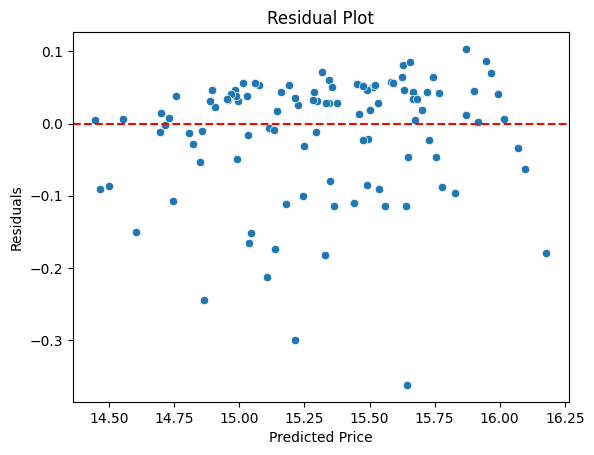

In [983]:
y_pred = model.predict(X_test)
residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


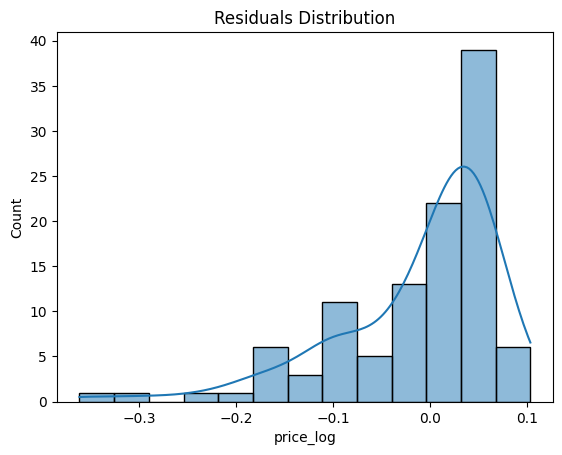

In [997]:
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()


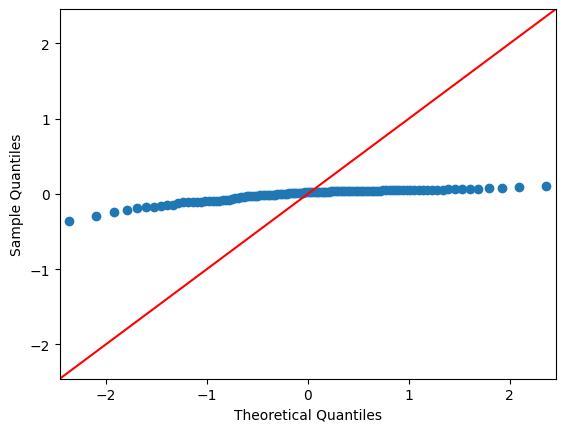

In [995]:
import statsmodels.api as sm
sm.qqplot(residuals, line='45')
plt.show()
